# Chronos-2 — Benchmark II Zero-shot (vs the Chronos-2 paper)

**Saudi Aramco — time-series foundation-model evaluation**

A zero-shot evaluation of **`amazon/chronos-2`** on the Chronos paper's **Benchmark
II** (25 datasets, `MAX_SERIES=1000`, gluonts `split` + MASE +
`MeanWeightedSumQuantileLoss`, the paper's aggregated relative score). Two modes:

1. **univariate** — every series forecast independently.
2. **cross-learning** — Chronos-2's *full cross-learning* in-context mode (the
   technical report's Benchmark II setting, arXiv:2510.15821 §5.1).

This notebook is **Chronos-2 only**: it reports Chronos-2's own zero-shot results and
checks them against the **Chronos-2 paper's** reported Benchmark II number
(reproduction check). The head-to-head against **Chronos-T5** lives in the sibling
comparison project **`../chronos2_t5/zero-shot/`** (dashboard, per-dataset scatter,
forecast plots); the model-vs-model architecture write-up is in
[`docs/CHRONOS2_VS_T5.md`](../docs/CHRONOS2_VS_T5.md).

> Heavy work is produced offline by `src/zero_shot/run_zeroshot_chronos2.py`; this notebook
> loads `results/zeroshot_chronos2_results.csv` and shows one small live demo.


## 1. Environment & imports

Reusable logic is imported from `src/` (`config`, `datasets_lib`,
`run_zeroshot_chronos2`); the notebook only orchestrates and displays.

In [1]:
import sys, platform, warnings
from pathlib import Path

# Quiet noisy library warnings (gluonts/pandas FutureWarnings, HF cache notices).
warnings.filterwarnings("ignore")
import datasets; datasets.logging.set_verbosity_error(); datasets.disable_progress_bars()

# Locate the project root portably (walk up to the dir containing src/config.py).
_here = Path.cwd()
for _c in (_here, *_here.parents):
    if (_c / "src" / "config.py").exists():
        ROOT = _c; break
else:
    raise FileNotFoundError("project root (src/config.py) not found from " + str(_here))
SRC = ROOT / "src"; [sys.path.insert(0, str(SRC / p)) for p in ("", "zero_shot", "one_shot")]

import numpy as np, pandas as pd, torch
from scipy.stats import gmean
import chronos
from chronos import BaseChronosPipeline
import datasets as hfds
from gluonts.dataset.split import split

from config import RESULTS_DIR as RESULTS, REFERENCE_DIR
import datasets_lib as D
import run_zeroshot_chronos2 as R2   # forecasters / to_gluonts_univariate / evaluate / constants

print("Python  :", platform.python_version())
print("torch   :", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("chronos :", chronos.__version__, "| model:", R2.MODEL_ID)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

Python  : 3.11.15
torch   : 2.9.1+cu128 | CUDA: True
chronos : 2.2.2 | model: amazon/chronos-2


## 2. Datasets — Benchmark II

25 of the paper's 27 Benchmark II (zero-shot) datasets from
`autogluon/chronos_datasets` (the 2 ETT datasets are absent from that repo).
Per-dataset horizon = paper Table 3; one held-out last-H window; seasonality is
inferred from each dataset's frequency by gluonts.

In [2]:
bench = pd.DataFrame(D.BENCHMARK_II, columns=["dataset", "horizon"])
print(f"{len(bench)} datasets, series cap = {D.MAX_SERIES}, quantiles = {R2.QUANTILES}")
bench

25 datasets, series cap = 1000, quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,dataset,horizon
0,monash_australian_electricity,48
1,monash_cif_2016,12
2,monash_car_parts,12
3,monash_covid_deaths,30
4,dominick,8
5,ercot,24
6,exchange_rate,30
7,monash_fred_md,12
8,monash_hospital,12
9,monash_m1_monthly,18


## 3. Chronos-2 in brief

How Chronos-2 turns a series into a forecast (full write-up incl. the Chronos-T5
contrast: [`docs/CHRONOS2_VS_T5.md`](../docs/CHRONOS2_VS_T5.md)):

* **Tokenization** — splits the series into **patches** of raw values fed through a
  residual MLP; **no discrete vocabulary** (unlike token-based models).
* **Scaling** — **InstanceNorm** (per-series standardize) + optional `arcsinh`.
* **Output** — a **direct quantile head** (21 trained quantiles): one forward pass
  emits the whole horizon as quantiles, **no sampling, no seed** → reproducible by
  construction. We request 9 levels (0.1…0.9) and build a gluonts `QuantileForecast`.
* **Group attention** — the mechanism behind multivariate / in-context learning.

**The two modes evaluated here:**
* **univariate** — every series forecast independently (each is its own group, so
  group attention is inert).
* **cross_learning** — Chronos-2 full cross-learning: inputs stay 1-D but every item
  in a batch shares one group id, so group attention shares information across the
  whole batch (`cross_learning=True`, group/batch size = `CROSS_LEARNING_BATCH`).

In [3]:
print("modes:", R2.MODES, "| cross-learning group/batch size:", R2.CROSS_LEARNING_BATCH)

modes: ('univariate', 'cross_learning') | cross-learning group/batch size: 100


## 4. Method (live demo, one small dataset)

For every dataset the same pipeline runs: build gluonts backtest windows →
`predict_quantiles` → gluonts `MASE` / `WQL`. Below is a **live zero-shot demo** on
`exchange_rate` (8 series) in *both* modes so real output appears inline; the full
25-dataset sweep is loaded in Section 5.

In [4]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
pipe = BaseChronosPipeline.from_pretrained(R2.MODEL_ID, device_map=dev, torch_dtype=R2.DTYPE)

cfg, h = "exchange_rate", 30
ds = hfds.load_dataset(R2.HF_REPO, cfg, split="train"); ds.set_format("numpy")
gts = R2.to_gluonts_univariate(ds, R2.MAX_SERIES)
_, tt = split(gts, offset=-h); td = tt.generate_instances(h, windows=1)
test_input = list(td.input)

fc_u = R2.forecast_univariate(pipe, test_input, h)
mase_u, wql_u = R2.evaluate(fc_u, td)
fc_c, n_series, n_groups = R2.forecast_cross_learning(pipe, test_input, h)
mase_c, wql_c = R2.evaluate(fc_c, td)
print(f"live demo  {cfg} (n={n_series}):")
print(f"  univariate     MASE={mase_u:.4f}  WQL={wql_u:.4f}")
print(f"  cross_learning MASE={mase_c:.4f}  WQL={wql_c:.4f}  (1 group of {n_series})")
del pipe
if dev == "cuda": torch.cuda.empty_cache()

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


0it [00:00, ?it/s]

8it [00:00, 375.36it/s]

0it [00:00, ?it/s]

8it [00:00, 363.64it/s]

live demo  exchange_rate (n=8):
  univariate     MASE=1.8164  WQL=0.0118
  cross_learning MASE=1.8491  WQL=0.0118  (1 group of 8)


## 5. Full results (precomputed)

Loaded from `results/zeroshot_chronos2_results.csv` — the canonical numbers from the
offline 25-dataset run, pivoted to univariate vs cross-learning per dataset.

In [5]:
raw = pd.read_csv(RESULTS / "zeroshot_chronos2_results.csv")
uni = raw[raw["mode"] == "univariate"].set_index("dataset")
xl  = raw[raw["mode"] == "cross_learning"].set_index("dataset")
res = pd.DataFrame({
    "n_series":  uni["n_series"],
    "MASE_uni":  uni["MASE"], "MASE_xl": xl["MASE"],
    "WQL_uni":   uni["WQL"],  "WQL_xl":  xl["WQL"],
}).reset_index()
res

,dataset,n_series,MASE_uni,MASE_xl,WQL_uni,WQL_xl
0,monash_australian_electricity,5,0.6272,0.6174,0.0307,0.0289
1,monash_cif_2016,72,0.9369,0.8374,0.0113,0.0081
2,monash_car_parts,1000,0.8324,0.8340,0.9787,0.9848
3,monash_covid_deaths,266,35.4297,32.5474,0.0396,0.0350
4,dominick,1000,0.9394,0.9409,0.3456,0.3401
5,ercot,8,0.8418,0.7846,0.0260,0.0249
6,exchange_rate,8,1.8164,1.8491,0.0118,0.0118
7,monash_fred_md,107,0.4848,0.4258,0.0200,0.0216
8,monash_hospital,767,0.7723,0.7401,0.0539,0.0510
9,monash_m1_monthly,617,1.0271,0.9849,0.1466,0.1184


### 5.1 Inference efficiency (latency + peak GPU memory)

Each run records per-dataset forecast **wall-time** and **peak GPU memory**.
Chronos-2 is a single forward pass (no autoregressive sampling), so it is fast and
light — and cross-learning, computing a whole batch as one group, is typically
faster and smaller-footprint than per-series univariate.

In [6]:
eff = raw.groupby("mode").agg(
    total_latency_s=("latency_s", "sum"),
    mean_ms_per_series=("ms_per_series", "mean"),
    peak_mem_mb=("peak_mem_mb", "max"),
).round(1)
eff

,total_latency_s,mean_ms_per_series,peak_mem_mb
mode,,,
cross_learning,28.6000,2.4000,"2,176.1000"
univariate,32.6000,6.9000,"7,026.4000"


## 6. Aggregated relative score — reproduction check vs the Chronos-2 paper

Headline metric: geometric mean of `model / Seasonal-Naive` across datasets (the
paper's aggregation; Seasonal-Naive reference bundled in `reference/`).

**Reproduction check.** The Chronos-2 paper (arXiv:2510.15821, Table 5) reports
Benchmark II as *skill scores* (WQL 46.6%, MASE 26.5%) and states `G = 1 - skill/100`,
where `G` is the geometric-mean relative error vs Seasonal-Naive — i.e. exactly our
aggregated score. So `Chronos-2 (paper)` = **WQL 0.534 / MASE 0.735**. Our runs should
land close; the small gap is expected — the paper uses **all 27 datasets + full data**,
we use **25 datasets + cap=1000 + bf16**.

In [7]:
base = pd.read_csv(REFERENCE_DIR / "seasonal-naive-zero-shot.csv").set_index("dataset")[["MASE", "WQL"]]
uni_m = uni[["MASE", "WQL"]]; xl_m = xl[["MASE", "WQL"]]
common = uni_m.index.intersection(base.index)

def agg(df): return (df.loc[common] / base.loc[common]).apply(gmean)
rows = {
    "C2 univariate":     agg(uni_m),
    "C2 cross-learning": agg(xl_m),
    # Chronos-2 paper Benchmark II (Table 5 skill scores) -> G = 1 - skill/100
    "Chronos-2 (paper)": pd.Series({"MASE": 1 - 0.265, "WQL": 1 - 0.466}),
}
headline = pd.DataFrame(rows).T[["WQL", "MASE"]]
print("Aggregated relative score (gmean of model / Seasonal-Naive; lower is better).")
print("Chronos-2 (paper) = skill scores from arXiv:2510.15821 Table 5, as G=1-skill/100.")
headline.round(3)

Aggregated relative score (gmean of model / Seasonal-Naive; lower is better).
Chronos-2 (paper) = skill scores from arXiv:2510.15821 Table 5, as G=1-skill/100.


,WQL,MASE
C2 univariate,0.5880,0.7730
C2 cross-learning,0.5630,0.7510
Chronos-2 (paper),0.5340,0.7350


### 6.1 Reproduction check chart + per-dataset (univariate vs cross-learning)

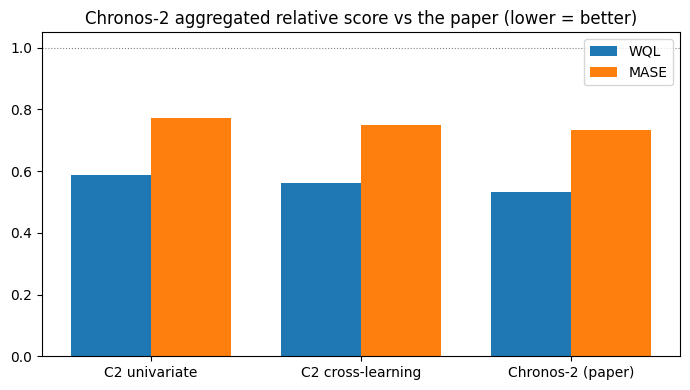

,MASE_uni,MASE_xl,WQL_uni,WQL_xl
dataset,,,,
monash_australian_electricity,0.6272,0.6174,0.0307,0.0289
monash_cif_2016,0.9369,0.8374,0.0113,0.0081
monash_car_parts,0.8324,0.8340,0.9787,0.9848
monash_covid_deaths,35.4297,32.5474,0.0396,0.0350
dominick,0.9394,0.9409,0.3456,0.3401
ercot,0.8418,0.7846,0.0260,0.0249
exchange_rate,1.8164,1.8491,0.0118,0.0118
monash_fred_md,0.4848,0.4258,0.0200,0.0216
monash_hospital,0.7723,0.7401,0.0539,0.0510


In [8]:
import matplotlib.pyplot as plt
runs = list(headline.index); x = np.arange(len(runs)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, headline["WQL"], w, label="WQL"); ax.bar(x + w/2, headline["MASE"], w, label="MASE")
ax.axhline(1.0, color="grey", lw=0.8, ls=":")            # = Seasonal-Naive
ax.set_xticks(x); ax.set_xticklabels(runs, fontsize=10)
ax.set_title("Chronos-2 aggregated relative score vs the paper (lower = better)")
ax.legend(); fig.tight_layout(); plt.show()

cmp = pd.DataFrame({"MASE_uni": uni_m.loc[common, "MASE"], "MASE_xl": xl_m.loc[common, "MASE"],
                    "WQL_uni":  uni_m.loc[common, "WQL"],  "WQL_xl":  xl_m.loc[common, "WQL"]})
cmp.round(4)

## 7. Findings

* **Reproduces the Chronos-2 paper.** Aggregated relative score (gmean of model /
  Seasonal-Naive, 25 datasets): C2 cross-learning **WQL 0.563 / MASE 0.751**, very close to
  the paper's Benchmark II number (WQL 0.534 / MASE 0.735); the small gap is expected — the
  paper uses all 27 datasets + full data, we use 25 + cap=1000 + bf16.
* **Cross-learning helps over univariate** (WQL 0.588→0.563, MASE 0.773→0.751), with the
  largest gains on short-history datasets (cif_2016, covid_deaths, fred_md, m1) — exactly
  the paper's finding for Benchmark II.
* **Determinism / efficiency** — Chronos-2 emits quantiles in one forward pass (no
  sampling/seed) so results are bit-reproducible; cross-learning (one group per batch) is
  also faster and lighter than per-series univariate (see §5.1).
* **Hard datasets** — intermittent / near-random-walk series (car_parts, m5, exchange_rate)
  and a few large panels (traffic, weather) gain little from cross-learning.

**Where the Chronos-T5 comparison lives:** the head-to-head (dashboard, per-dataset scatter,
forecast plots, efficiency) is in the sibling project **`../chronos2_t5/zero-shot/`**.
Genuine shared-dynamics *multivariate* / covariate forecasting is the report's fev-bench /
GIFT-Eval story — a natural next step.


## 8. Per-dataset forecast visualizations (native benchmark horizon)

One representative series per Benchmark II dataset, each showing **recent context
(actual) → forecast horizon** with the **held-out actual** overlaid on the forecast
(median + 10–90% band); the vertical line marks the forecast origin.

* **Horizon** — each dataset's *own* benchmark horizon (paper Table 3: 4–56 steps),
  i.e. the setting Chronos-2 is actually scored on (not a long-horizon showcase).
* **Context** shown = `max(3·H, 60)` recent steps so the horizon stays visible.
* Saved individually to `results/forecasts/chronos2/` + a 5×5 overview grid below.
  (The Chronos-T5 forecasts and the full T5-vs-C2 comparison live in `../chronos2_t5/zero-shot/`.)

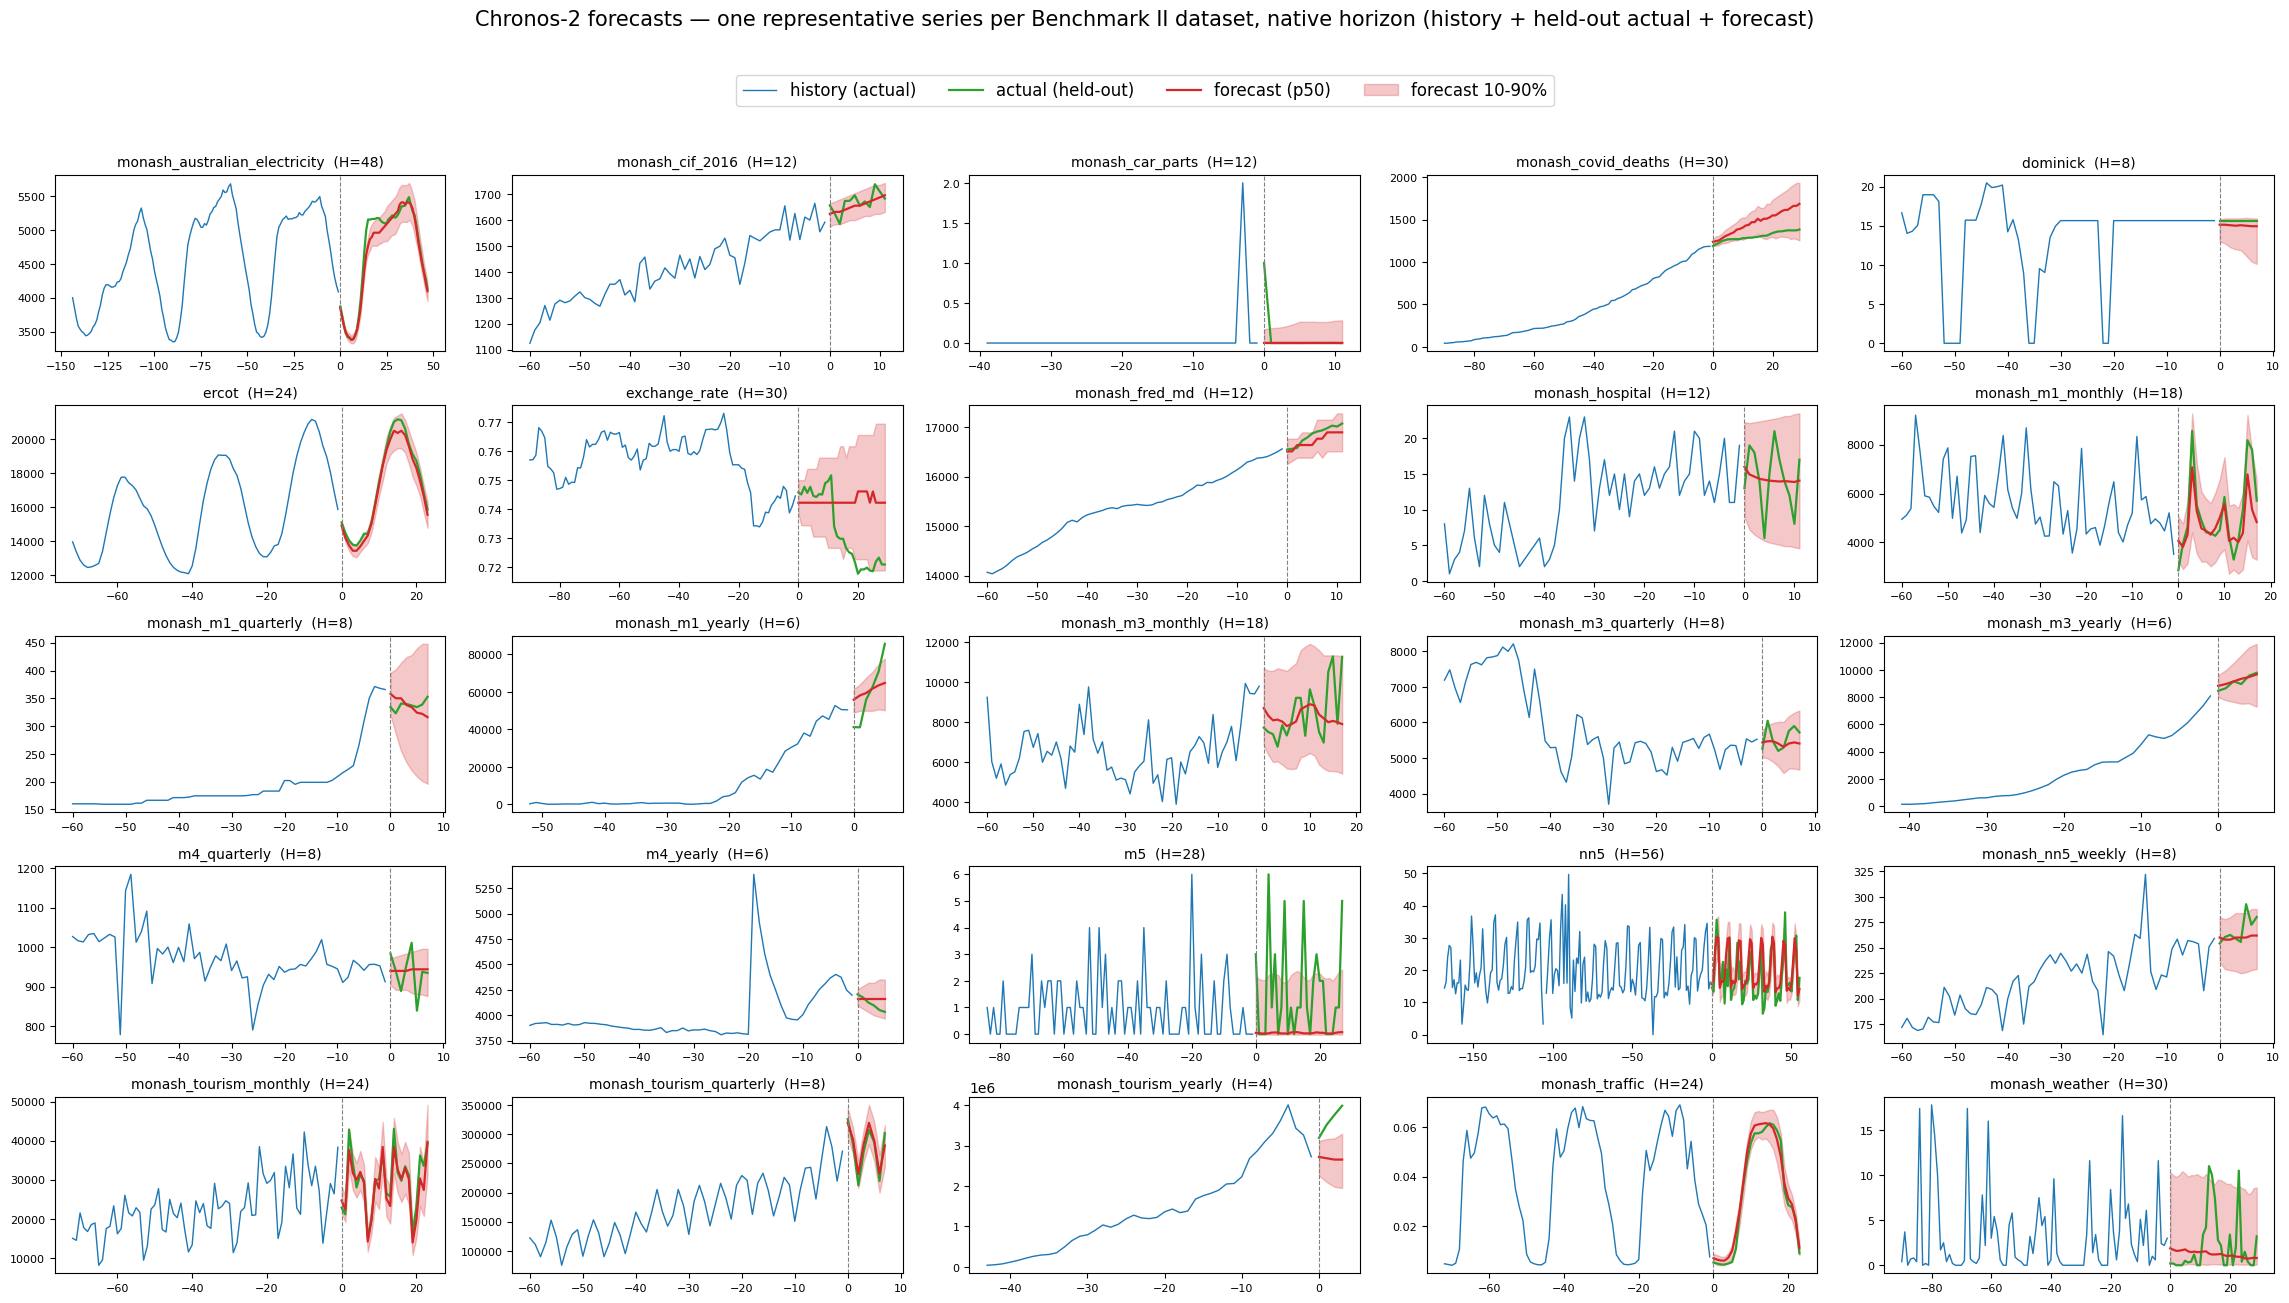

Saved 25 plots -> results\forecasts\chronos2


In [9]:
import datasets as hfds, matplotlib.pyplot as plt
import torch as _torch

FC_DIR = RESULTS / "forecasts"
Qs = [0.1, 0.5, 0.9]
HZN = dict(D.BENCHMARK_II)        # dataset -> native benchmark horizon (Table 3)

def pick_series(ds):
    """Representative series = the one with the most finite observations (richest context)."""
    gts = R2.to_gluonts_univariate(ds, R2.MAX_SERIES)
    return np.asarray(max(gts, key=lambda e: int(np.isfinite(e["target"]).sum()))["target"],
                      dtype=np.float32)

# pick the representative series once per dataset (reused for both models)
SERIES = {}
for cfg, H in D.BENCHMARK_II:
    ds = hfds.load_dataset(R2.HF_REPO, cfg, split="train"); ds.set_format("numpy")
    SERIES[cfg] = pick_series(ds)

def forecast(pipe, series, H, kind):
    ctx = series[:len(series) - H]
    kw = dict(prediction_length=H, quantile_levels=Qs)
    if kind == "t5":
        _torch.manual_seed(0); kw["num_samples"] = 20          # seeded 20-sample quantiles
    else:
        kw["limit_prediction_length"] = False
    # Chronos-T5 requires torch.Tensor context (Chronos-2 also accepts it) -> always pass a tensor
    qz, _ = pipe.predict_quantiles([_torch.tensor(ctx)], **kw)
    a = qz[0]
    a = a.cpu().numpy() if hasattr(a, "cpu") else np.asarray(a)
    if a.ndim == 3:                                            # Chronos-2: (n_variates, H, Q) -> (H, Q)
        a = a[0]
    return ctx, series[len(series) - H:], a                   # ctx, actual_future, (H, 3)

def draw(ax, name, ctx, fut, q, H):
    D_show = max(3 * H, 60); show = ctx[-D_show:]
    xc = np.arange(-len(show), 0); xf = np.arange(0, H)
    ax.plot(xc, show, color="C0", lw=1.0, label="history (actual)")
    ax.plot(xf, fut, color="C2", lw=1.6, label="actual (held-out)")
    ax.plot(xf, q[:, 1], color="C3", lw=1.6, label="forecast (p50)")
    ax.fill_between(xf, q[:, 0], q[:, 2], color="C3", alpha=0.25, label="forecast 10-90%")
    ax.axvline(0, color="grey", ls="--", lw=0.8)
    ax.set_title(f"{name}  (H={H})", fontsize=10); ax.tick_params(labelsize=8)

def run_model(model_id, folder, kind, title):
    pipe = BaseChronosPipeline.from_pretrained(model_id, device_map="cuda", torch_dtype=R2.DTYPE)
    sub = FC_DIR / folder; sub.mkdir(parents=True, exist_ok=True)
    res = []
    for cfg, series in SERIES.items():
        H = HZN[cfg]
        ctx, fut, q = forecast(pipe, series, H, kind)
        res.append((cfg, ctx, fut, q, H))
        f1, a1 = plt.subplots(figsize=(7.2, 3.2)); draw(a1, cfg, ctx, fut, q, H)
        a1.set_xlabel("steps from forecast origin"); a1.legend(fontsize=8, loc="upper left")
        f1.tight_layout(); f1.savefig(sub / f"{cfg}.png", dpi=130, bbox_inches="tight"); plt.close(f1)
    del pipe
    if _torch.cuda.is_available(): _torch.cuda.empty_cache()
    # 5x5 overview grid
    fig, axes = plt.subplots(5, 5, figsize=(23, 13))
    for ax, r in zip(axes.ravel(), res): draw(ax, *r)
    for ax in axes.ravel()[len(res):]: ax.axis("off")
    h, l = axes.ravel()[0].get_legend_handles_labels()
    fig.suptitle(f"{title} — one representative series per Benchmark II dataset, "
                 f"native horizon (history + held-out actual + forecast)", fontsize=15, y=0.999)
    # legend on its own row below the title (no overlap)
    fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=4, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.925])
    fig.savefig(sub / "_overview_grid.png", dpi=110, bbox_inches="tight"); plt.show()
    print(f"Saved {len(res)} plots -> {sub}")

run_model(R2.MODEL_ID, "chronos2", "c2", "Chronos-2 forecasts")